# 417. Pacific Atlantic Water Flow

There is an m x n rectangular island that borders both the Pacific Ocean and Atlantic Ocean. The Pacific Ocean touches the island's left and top edges, and the Atlantic Ocean touches the island's right and bottom edges.

The island is partitioned into a grid of square cells. You are given an m x n integer matrix heights where heights[r][c] represents the height above sea level of the cell at coordinate (r, c).

The island receives a lot of rain, and the rain water can flow to neighboring cells directly north, south, east, and west if the neighboring cell's height is less than or equal to the current cell's height. Water can flow from any cell adjacent to an ocean into the ocean.

Return a 2D list of grid coordinates result where result[i] = [ri, ci] denotes that rain water can flow from cell (ri, ci) to both the Pacific and Atlantic oceans.

 

Example 1:

417. Pacific Atlantic Water Flow
Medium
Topics
premium lock icon
Companies
There is an m x n rectangular island that borders both the Pacific Ocean and Atlantic Ocean. The Pacific Ocean touches the island's left and top edges, and the Atlantic Ocean touches the island's right and bottom edges.

The island is partitioned into a grid of square cells. You are given an m x n integer matrix heights where heights[r][c] represents the height above sea level of the cell at coordinate (r, c).

The island receives a lot of rain, and the rain water can flow to neighboring cells directly north, south, east, and west if the neighboring cell's height is less than or equal to the current cell's height. Water can flow from any cell adjacent to an ocean into the ocean.

Return a 2D list of grid coordinates result where result[i] = [ri, ci] denotes that rain water can flow from cell (ri, ci) to both the Pacific and Atlantic oceans.

Example 1:

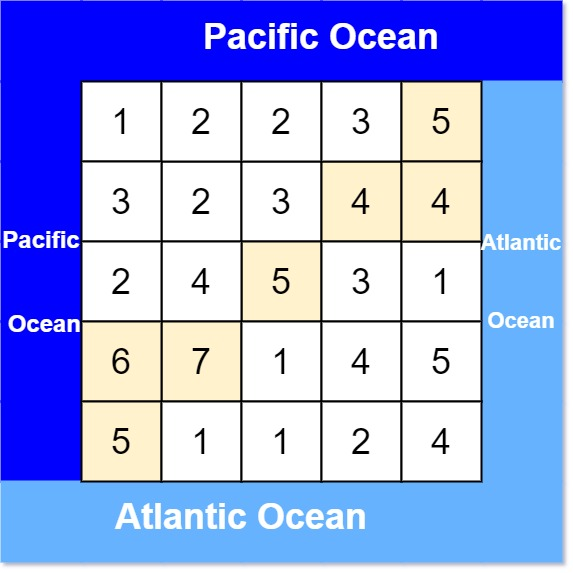

```
Input: heights = [[1,2,2,3,5],[3,2,3,4,4],[2,4,5,3,1],[6,7,1,4,5],[5,1,1,2,4]]
Output: [[0,4],[1,3],[1,4],[2,2],[3,0],[3,1],[4,0]]
Explanation: The following cells can flow to the Pacific and Atlantic oceans, as shown below:
[0,4]: [0,4] -> Pacific Ocean 
       [0,4] -> Atlantic Ocean
[1,3]: [1,3] -> [0,3] -> Pacific Ocean 
       [1,3] -> [1,4] -> Atlantic Ocean
[1,4]: [1,4] -> [1,3] -> [0,3] -> Pacific Ocean 
       [1,4] -> Atlantic Ocean
[2,2]: [2,2] -> [1,2] -> [0,2] -> Pacific Ocean 
       [2,2] -> [2,3] -> [2,4] -> Atlantic Ocean
[3,0]: [3,0] -> Pacific Ocean 
       [3,0] -> [4,0] -> Atlantic Ocean
[3,1]: [3,1] -> [3,0] -> Pacific Ocean 
       [3,1] -> [4,1] -> Atlantic Ocean
[4,0]: [4,0] -> Pacific Ocean 
       [4,0] -> Atlantic Ocean
```

m == heights.length
n == heights[r].length
1 <= m, n <= 200
0 <= heights[r][c] <= 105

In [ ]:
from typing import List
from collections import deque

class Solution:
    def pacificAtlantic(self, heights: List[List[int]]) -> List[List[int]]:
        TOTAL_ROWS = len(heights)
        TOTAL_COLUMNS = len(heights[0])
        
        pacific_visited = set()
        atlantic_visited = set()
        pacific_queue = deque()
        atlantic_queue = deque()

        # Initialize Pacific Ocean (top and left edges)
        for r in range(TOTAL_ROWS):
            pacific_visited.add((r, 0))
            pacific_queue.append((r, 0))
            atlantic_visited.add((r, TOTAL_COLUMNS - 1))
            atlantic_queue.append((r, TOTAL_COLUMNS - 1))
        
        for c in range(TOTAL_COLUMNS):
            pacific_visited.add((0, c))
            pacific_queue.append((0, c))
            atlantic_visited.add((TOTAL_ROWS - 1, c))
            atlantic_queue.append((TOTAL_ROWS - 1, c))

        def bfs(queue, visited):
            reachable = set()
            while queue:
                row, col = queue.popleft()
                reachable.add((row, col))
                
                for dr, dc in [(0, 1), (1, 0), (-1, 0), (0, -1)]:
                    new_row, new_col = row + dr, col + dc
                    
                    if (0 <= new_row < TOTAL_ROWS and 
                        0 <= new_col < TOTAL_COLUMNS and 
                        heights[new_row][new_col] >= heights[row][col] and 
                        (new_row, new_col) not in visited):
                        
                        visited.add((new_row, new_col))
                        queue.append((new_row, new_col))
            
            return reachable

        pacific_reachable = bfs(pacific_queue, pacific_visited)
        atlantic_reachable = bfs(atlantic_queue, atlantic_visited)
        pacific_atlatic_reachable = pacific_reachable.intersection(atlantic_reachable)
        return [list(coord) for coord in pacific_atlatic_reachable]